# Chromosome IV - Combined Replication Profile Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [24]:
from src.CombinedReplicateDeconvolutionRunner import main as fit_combined_replication
from src.config import load_default_configs
config1, config2 = load_default_chrom_configs()
    
out_dir = 'output/prototype_run/'

combined_runner = fit_combined_replication(4, 10, out_dir, config1, config2)


Loading initial parameters from CLOCCS runs
todo: Loading testing config from replication deconvolution
Shifting mu0, gamma1, and gamma2 for the alpha parameter
Omit windows with less than 75% read coverage.
Omit windows with less than 75% read coverage.
Initializing N using config H.
Deconvolving 700 regions
Initializing B using timepoint 0
Initializing N using config H.
Deconvolving 700 regions
Initializing B using timepoint 0
Running initial combined deconvolution for F, N, and B
Epoch: 0
[0]: Running iterative updates and combined deconvolution for F, N, and B
00:00:11.549
mu0_1          9.361663
lambda_1      60.397553
delta_1       14.577271
sigma0_1       5.884135
sigmav_1       0.044401
gamma1_1       0.586077
gamma2_1       1.000000
halted_1       0.000050
mu0_2         20.023800
delta_2        9.154000
sigma0_2       3.919000
sigmav_2       0.115000
lambda_2      60.000000
gamma1_2       0.663000
gamma2_2       1.000000
halted_2       0.000002
opt_H_rn_1     0.005713
opt_H_rn

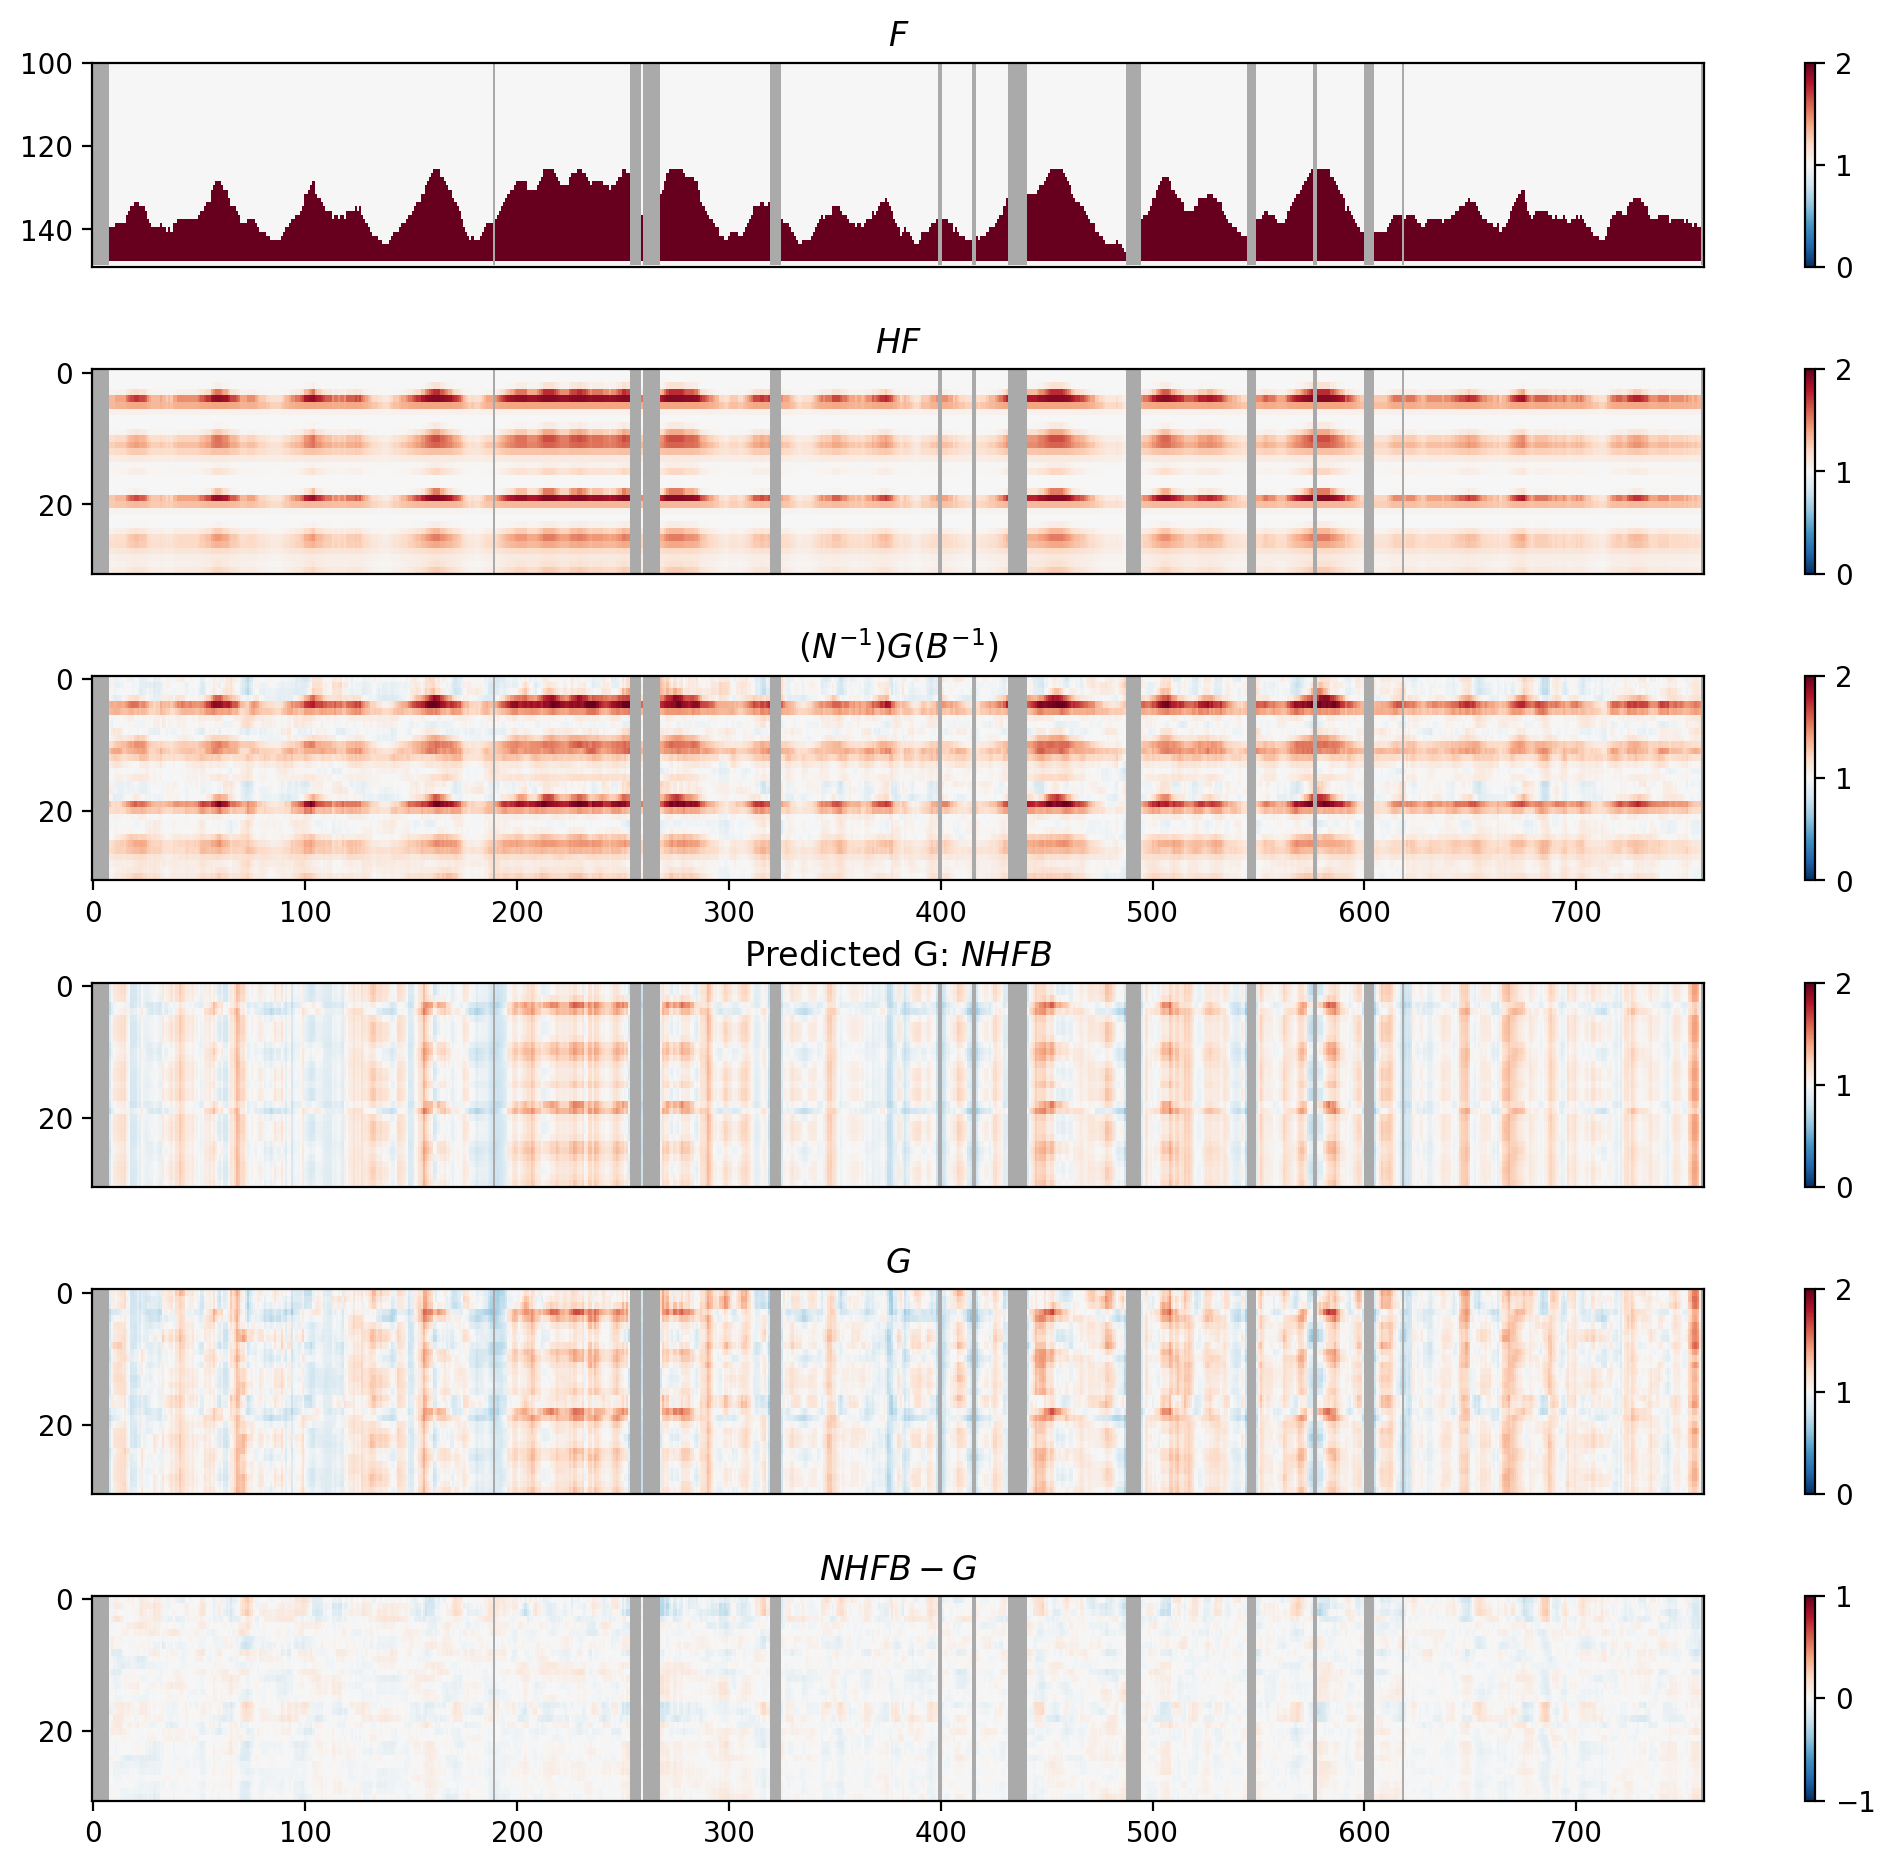

In [26]:
fig = combined_runner.deconvolution.plot_heatmaps()

In [52]:
config1, config2 = load_default_chrom_configs(from_CLOCCS=True)


Shifting mu0, gamma1, and gamma2, for alpha...


In [57]:
# Load the replicate 1 and 2 parameters and deconvolve combined

params_rep1 = pd.read_csv('output/prototype_pipeline_subset/parameter_updates_rep1_chr4.csv')
parameters = params_rep1.iloc[-1]

mu0, gamma1, gamma2, sigma0 = parameters.mu0, parameters.gamma1, \
    parameters.gamma2, parameters.sigma0
mu0, gamma1, gamma2, sigma0

config1.params_dic['mu0'] = mu0
config1.params_dic['gamma1'] = gamma1
config1.params_dic['gamma2'] = gamma2
config1.params_dic['sigma0'] = sigma0
config1.params_dic['alpha'] = 0
config1.update_timepoints()
H1 = config1.calculate_H()
config1.params_dic

{'mu0': 13.549227083922458,
 'delta': 8.1805,
 'sigma0': 3.656160348296892,
 'sigmav': 0.1424,
 'lambda': 68.1914,
 'gamma1': 0.5590209539125397,
 'gamma2': 1.0,
 'halted': 0.2245,
 'alpha': 0}

In [58]:
# Load the replicate 1 and 2 parameters and deconvolve combined

params_rep2 = pd.read_csv('output/prototype_pipeline_subset/parameter_updates_rep2_chr4.csv')
parameters = params_rep2.iloc[-1]

mu0, gamma1, gamma2, sigma0 = parameters.mu0, parameters.gamma1, \
    parameters.gamma2, parameters.sigma0
mu0, gamma1, gamma2, sigma0

config2.params_dic['mu0'] = mu0
config2.params_dic['gamma1'] = gamma1
config2.params_dic['gamma2'] = gamma2
config2.params_dic['sigma0'] = sigma0
config2.params_dic['alpha'] = 0
config2.update_timepoints()
H2 = config2.calculate_H()
config2.params_dic

{'mu0': 12.497440321289709,
 'delta': 10.8953,
 'sigma0': 4.031124730419044,
 'sigmav': 0.1297,
 'lambda': 60.2093,
 'gamma1': 0.5060627807159651,
 'gamma2': 1.0,
 'halted': 0.2906,
 'alpha': 0}

In [ ]:
# todo initialize load of N and B

In [81]:
from src.config import load_default_configs

out_dir = 'output/prototype_pipeline_subset/'
    
combined_runner = fit_combined_replication(4, 1, out_dir, config1, config2)


Omit windows with less than 75% read coverage.
Omit windows with less than 75% read coverage.
Initializing N using config H.
Deconvolving 700 regions
Initializing B using timepoint 0
Initializing N using config H.
Deconvolving 700 regions
Initializing B using timepoint 0
H, G, N, B shapes: (31, 149) (31, 700) (31, 31) (700, 700)
Running initial combined deconvolution for F, N, and B
Epoch: 0
[0]: Running iterative updates and combined deconvolution for F, N, and B
00:00:11.470
mu0_1         13.549227
delta_1        8.180500
sigma0_1       3.656160
sigmav_1       0.142400
lambda_1      68.191400
gamma1_1       0.559021
gamma2_1       1.000000
halted_1       0.224500
mu0_2         12.497440
delta_2       10.895300
sigma0_2       4.031125
sigmav_2       0.129700
lambda_2      60.209300
gamma1_2       0.506063
gamma2_2       1.000000
halted_2       0.290600
opt_H_rn_1     0.003527
opt_H_rn_2     0.002381
F_rn           0.002970
Name: 0, dtype: float64
Creating directory: output/prototype_p

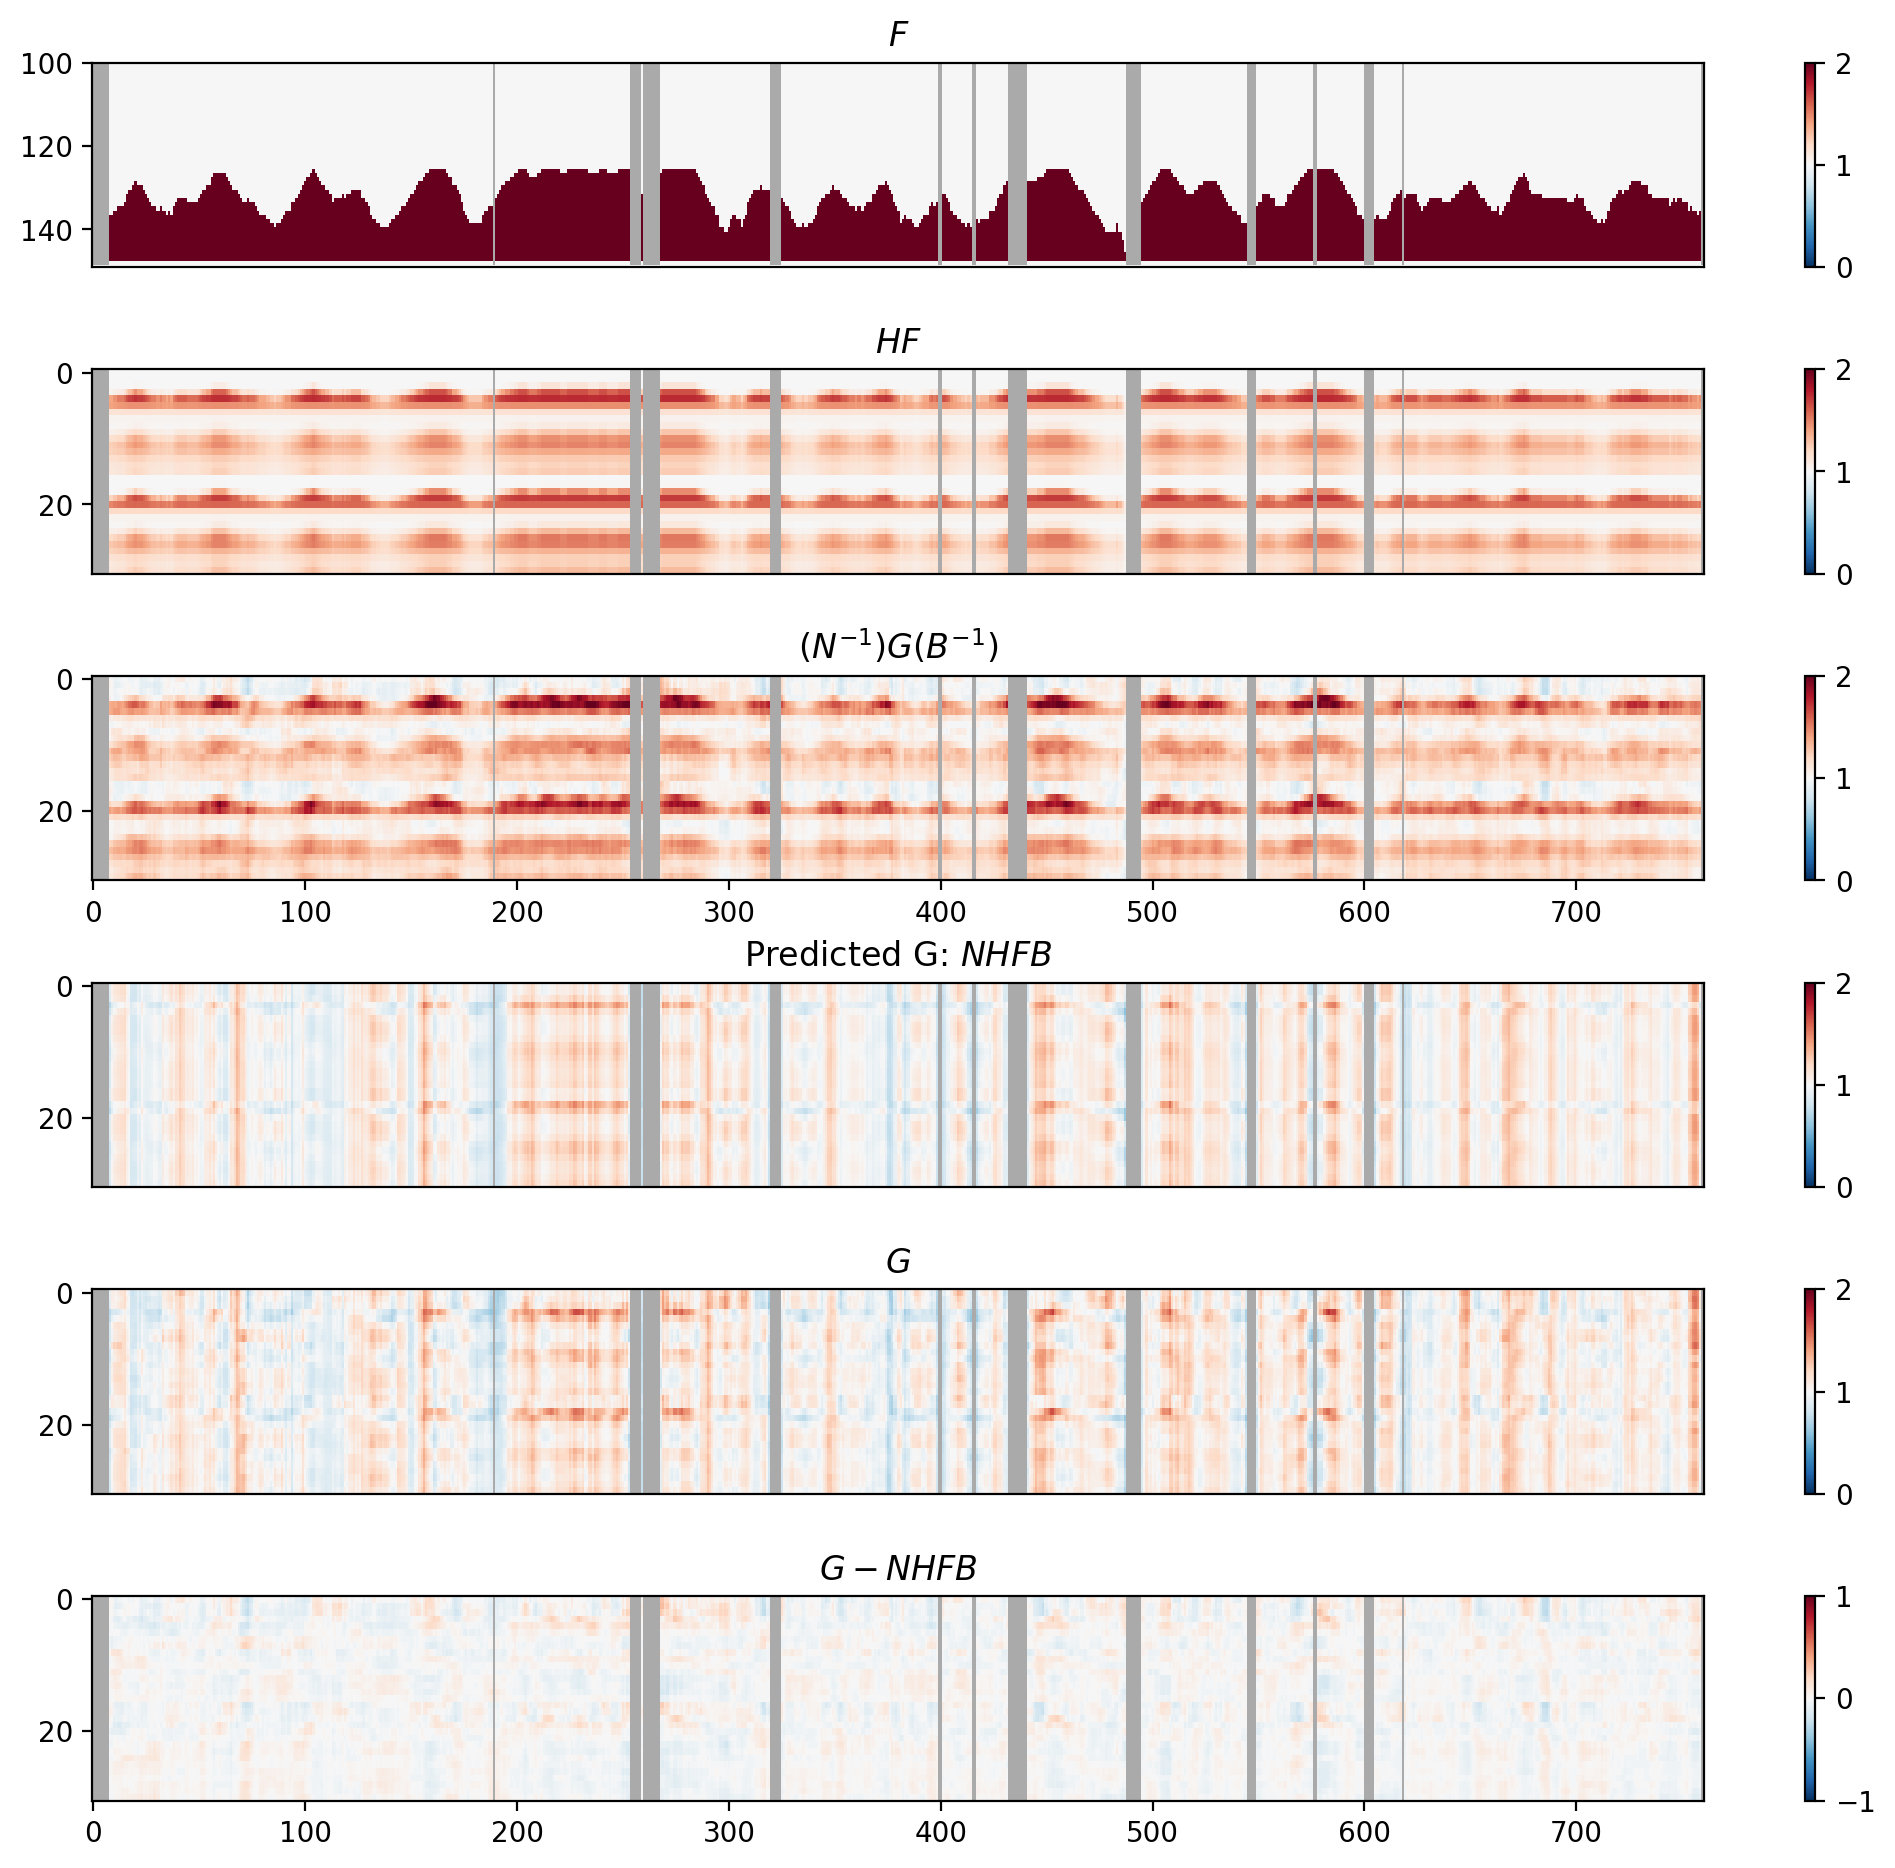

In [83]:
fig = combined_runner.deconvolution.plot_heatmaps()

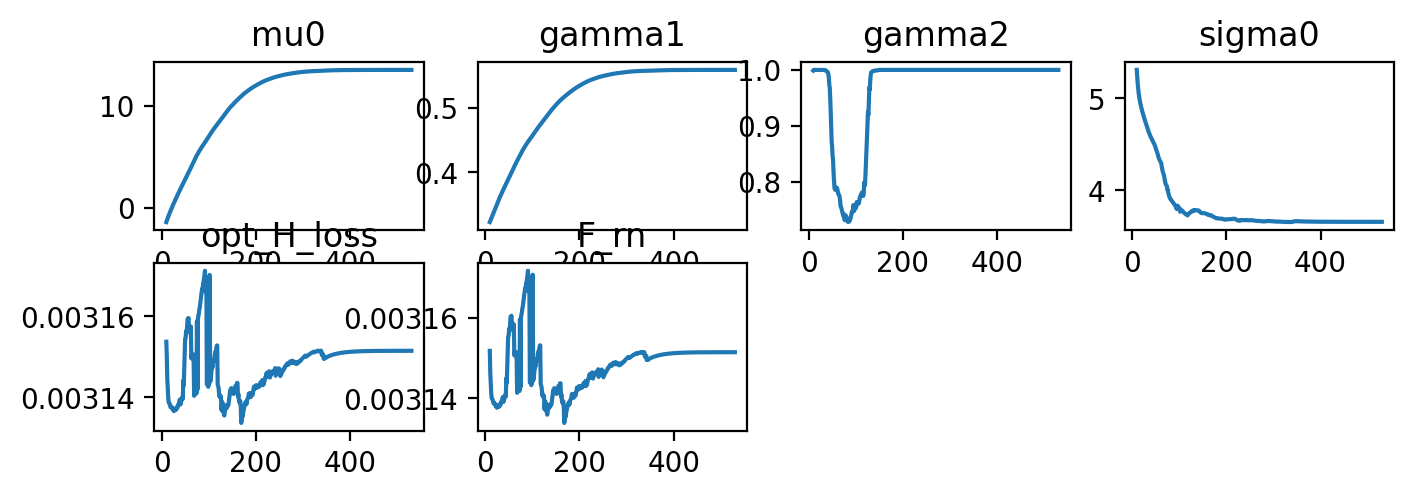

In [92]:
rep1_updates = pd.read_csv('output/prototype_pipeline_subset/parameter_updates_rep1_chr4.csv')

rows, cols = 4, 4

plt.figure(figsize=(8, 5))
for i, col in enumerate(rep1_updates.columns[1:]):
    plt.subplot(rows, cols, i+1)
    plt.plot(rep1_updates[col][10:])
    plt.title(col)


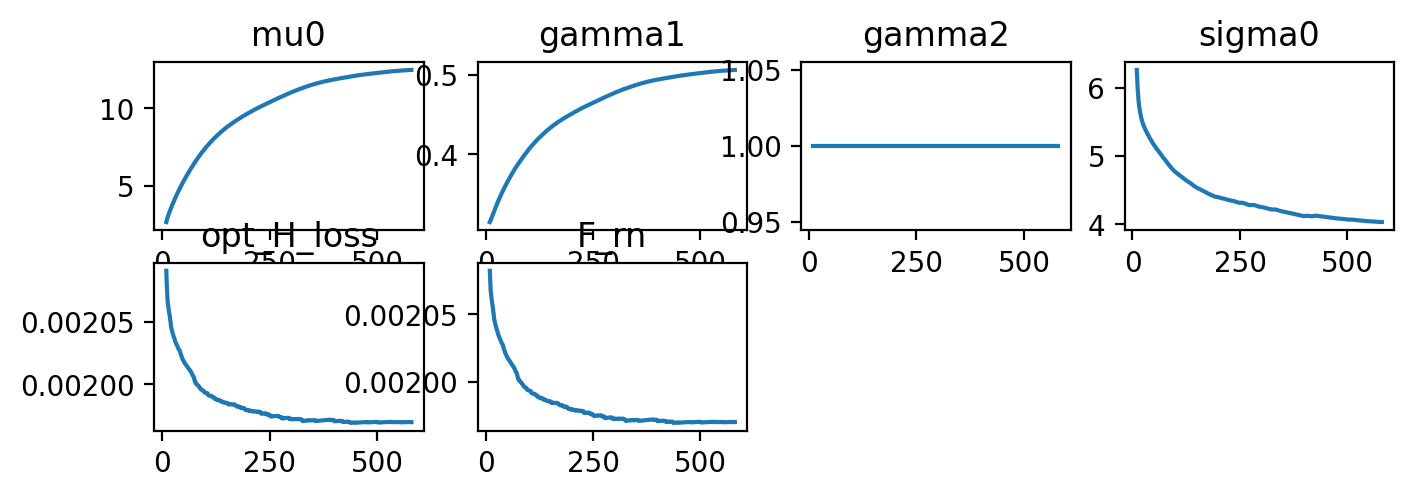

In [93]:
rep1_updates = pd.read_csv('output/prototype_pipeline_subset/parameter_updates_rep2_chr4.csv')

rows, cols = 4, 4

plt.figure(figsize=(8, 5))
for i, col in enumerate(rep1_updates.columns[1:]):
    plt.subplot(rows, cols, i+1)
    plt.plot(rep1_updates[col][10:])
    plt.title(col)


In [ ]:
# Looks to have converged, update to converge lambda and delta? halted?
